# Range generation

Want to first build a data pipeline for ranges, including the base features. Will later build a better generator all types of appliances


In [21]:
import random
from faker import Faker
from matplotlib import pyplot as plt

fake = Faker()

range_types = ["gas", "electric", "induction", "dual fuel"] #to start the generation

#this keeps it realistic, some brands dont make certain types of ranges
brands_by_type = {
    "gas": ["Frigidaire", "GE", "Whirlpool", "LG", "Samsung", "KitchenAid", "Wolf"],
    "electric": ["Frigidaire", "GE", "Whirlpool", "LG", "Samsung", "Bosch"],
    "induction": ["GE", "Samsung", "Bosch", "Cafe", "Miele", "Fisher & Paykel"],
    "dual fuel": ["KitchenAid", "Cafe", "Thermador", "Wolf", "Monogram"],
}

#to account for possibly more features in a more premium product
brand_tiers = {
    "budget": ["Frigidaire", "Whirlpool"],
    "mainstream": ["GE", "LG", "Samsung"],
    "premium": ["KitchenAid", "Bosch", "Cafe"],
    "luxury": ["Miele", "Fisher & Paykel", "Thermador", "Wolf", "Monogram"],
}

# googled avg price, took median of the midrange prices
base_price_by_type = {
    "electric": 1200,
    "gas": 1600,
    "induction": 2400,
    "dual fuel": 3250,
}

#to account for price inflation based off the tier
tier_multiplier = {
    "budget": 0.85,
    "mainstream": 1.0,
    "premium": 1.45,
    "luxury": 2.4,
}

#the better the tier, the more features
tier_feature_count = {
    "budget": [1, 3],
    "mainstream": [2, 4],
    "premium": [2, 5],
    "luxury": [4, 7],
}

#to get the brand tier - affects the number of features, price and whatnot
def get_brand_tier(brand):
    for tier in brand_tiers.keys():
        if brand in brand_tiers[tier]:
            return tier
    return None

#actual range generation funciton
def generate_range():

    #choose some stuff, the brand and brand tier depend on the range type, same with features
    range_type = random.choice(range_types)

    brand = random.choice(brands_by_type[range_type])
    brand_tier = get_brand_tier(brand)


    #budget tiers will not have extremely wide ranges, so changed so that each tier has their own sizes to try and make more realistic
    if get_brand_tier(brand) == "budget":
        width = random.choices([24, 30], weights=[20, 80], k=1)[0]

    if get_brand_tier(brand) == "mainstream":
        width = random.choices([24, 30, 36],weights=[10, 75, 15], k=1)[0]

    if get_brand_tier(brand) == "premium":
        width = random.choices([30, 36, 48], weights=[40, 50, 10], k=1 )[0]

    if get_brand_tier(brand) == "luxury":
        width = random.choices( [30, 36, 48, 60], weights=[15, 45, 30, 10], k=1)[0]

    depth = random.choice([25, 26, 27, 28, 29, 30, 31])

    height = random.choices([35, 36, 37, 38, 39, 40, 42, 44, 46], weights=[8, 35, 15, 12, 8, 8, 6, 5, 3],k=1)[0]

    burners = random.choice([4, 5, 6])
    features = random.sample(
        ["Air Fry", "Convection", "Self Clean", "WiFi", "Griddle", "Steam Clean", "Smart enabled"],
        k=random.randint(tier_feature_count[brand_tier][0], tier_feature_count[brand_tier][1]))
    finish = random.choice(["Stainless Steel", "Black Stainless", "White", "Black"])

    # somewhat accurate price generation
    price = base_price_by_type[range_type]
    price *= tier_multiplier[brand_tier]

    # width should affect price the most
    if width == 24:
        price *= 0.85
    elif width == 30:
        price *= 1.0
    elif width == 36:
        price *= 1.35
    elif width == 48:
        price *= 2.1
    elif width == 60:
        price *= 3.0

    # depth and height affect price, but less than width
    price *= 1 + ((depth - 26) * 0.03)
    price *= 1 + ((height - 36) * 0.015)

    # more burners usually means higher price
    if burners == 5:
        price *= 1.08
    elif burners == 6:
        price *= 1.18

    # features still add value
    price += len(features) * 150

    # adding some variance in price
    price *= random.uniform(0.9, 1.1)
    price = round(price, -1)

    #pretty random ratings - probably will try to push the higher rated stuff....
    rating = round(random.normalvariate(4.2, 0.25), 1)
    rating = min(max(rating, 3.2), 5.0)

    return {
        "product_id": fake.unique.bothify("RNG-#####"),
        "category": "range",
        "range_type": range_type,
        "brand": brand,
        "brand_tier": brand_tier,
        "width_inches": width,
        "height_inches": height,
        "depth_inches": depth,
        "burners": burners,
        "finish": finish,
        "features": features,
        "price": int(price),
        "rating": rating,
    }


print(generate_range())


{'product_id': 'RNG-97216', 'category': 'range', 'range_type': 'electric', 'brand': 'Samsung', 'brand_tier': 'mainstream', 'width_inches': 30, 'height_inches': 37, 'depth_inches': 27, 'burners': 6, 'finish': 'Black', 'features': ['Self Clean', 'Smart enabled', 'Griddle', 'Air Fry'], 'price': 1870, 'rating': 3.9}


In [22]:
my_data = []
import pandas as pd
for _ in range(25000):
    my_data.append(generate_range())

data = pd.DataFrame(my_data)

print(data)


      product_id category range_type       brand  brand_tier  width_inches  \
0      RNG-18368    range  induction       Bosch     premium            30   
1      RNG-90844    range  dual fuel  KitchenAid     premium            36   
2      RNG-83719    range  dual fuel        Cafe     premium            36   
3      RNG-64171    range  induction     Samsung  mainstream            30   
4      RNG-09976    range  dual fuel    Monogram      luxury            36   
...          ...      ...        ...         ...         ...           ...   
24995  RNG-27073    range   electric          LG  mainstream            30   
24996  RNG-87896    range        gas   Whirlpool      budget            30   
24997  RNG-57310    range   electric          GE  mainstream            36   
24998  RNG-28637    range        gas        Wolf      luxury            30   
24999  RNG-85286    range   electric          GE  mainstream            30   

       height_inches  depth_inches  burners           finish  \

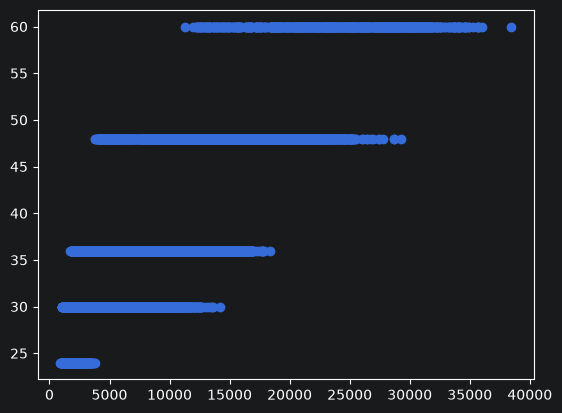

In [23]:
import matplotlib.pyplot as mpl
fig, ax = plt.subplots()

#just to see if mat plotlib works, was playing around with a couple features to make the pricing a tad more realistic
x = data["price"]
y = data["width_inches"]

ax.scatter(x, y)

This concludes data generation. I decided to make my own data, as i was unsure of what the robots.txt text meant, did not want strain the servers and i could not find a data set to use for this project. This notebook is just to make all the data... i want to keep this as organized as possible

In [25]:
data.to_csv("ranges.csv")